# Sentiment Analysis Notebook

This notebook builds a binary sentiment classifier for IMDb movie reviews. Each section showcases a core machine learning step: loading data, preparing text, building a neural network, training it, and checking how well it generalizes.

## Why this notebook matters
- It shows the full pipeline from raw text to prediction.
- It introduces the main ideas behind natural language processing with neural networks.
- It demonstrates how TensorFlow and Keras handle preprocessing, model building, training, and evaluation.

## Key concepts you will see
- Text tokenization and padding
- Embeddings
- Recurrent neural networks with LSTM layers
- Binary classification
- Train/validation/test splits
- Overfitting and generalization

## Real-world applications
- Review sentiment analysis
- Customer feedback triage
- Social media monitoring
- Moderation and intent classification

In [38]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from collections import Counter

# Loading the IMDb dataset

This section downloads the IMDb reviews dataset from TensorFlow Datasets and loads it as supervised learning data.

## Why it is necessary
Machine learning models do not learn directly from raw files. They need the data loaded into a format that TensorFlow can iterate over efficiently.

## AI concepts involved
- A dataset is the source of examples the model learns from.
- Supervised learning means each review has a label: positive or negative.
- The train split is what the model learns from.

In [43]:
dataset, info = tfds.load(
    "imdb_reviews",
    with_info=True,
    as_supervised=True
)

print(dataset)
print(info)


{'train': <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>, 'test': <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>, 'unsupervised': <_PrefetchDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>}
tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir='/home

# Exploring the text data

Here we convert the TensorFlow dataset into plain Python structures so we can inspect the reviews and labels.

## What this teaches
- How to move from a `tf.data.Dataset` into arrays and lists for analysis.
- How to check class balance before training.
- Why review length matters for padding.

## Key ideas
- Class imbalance can bias a classifier toward the majority class.
- Sequence length matters because neural networks expect fixed-size inputs after padding.
- Looking at raw examples helps you verify that preprocessing matches the problem.

Total training samples: 25000
Positive reviews: 12500
Negative reviews: 12500
Average review length: 233.79 words
Max review length: 2470 words
Min review length: 10 words

Sample review:
This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but


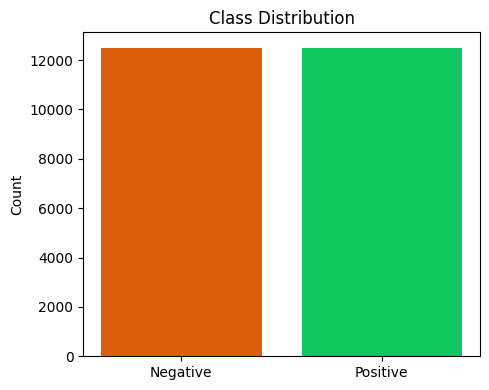

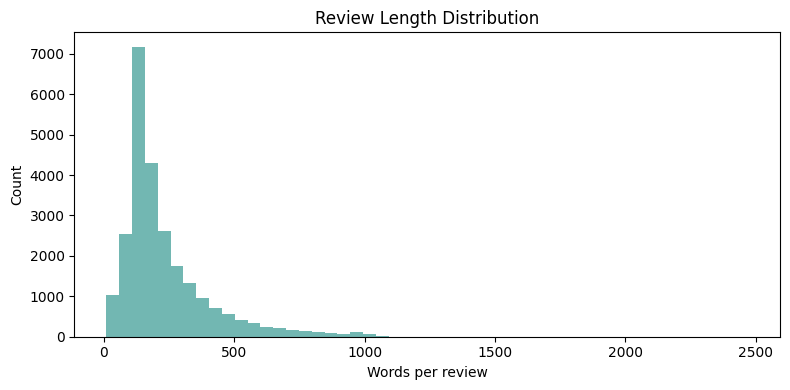

In [46]:
texts = []
labels = []

for text, label in tfds.as_numpy(dataset['train']):
    texts.append(text.decode('utf-8'))
    labels.append(label)

labels = np.array(labels)

print(f'Total training samples: {len(texts)}')
print(f'Positive reviews: {int(np.sum(labels))}')
print(f'Negative reviews: {len(labels) - int(np.sum(labels))}')

review_lengths = np.array([len(text.split()) for text in texts])
print(f'Average review length: {review_lengths.mean():.2f} words')
print(f'Max review length: {review_lengths.max()} words')
print(f'Min review length: {review_lengths.min()} words')

print('\nSample review:')
print(texts[0][:500])

class_counts = np.bincount(labels)
plt.figure(figsize=(5, 4))
plt.bar(['Negative', 'Positive'], class_counts, color=["#dd5f0a", "#0ec761"])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(review_lengths, bins=50, color='#72b7b2')
plt.title('Review Length Distribution')
plt.xlabel('Words per review')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Tokenization and padding

This section turns text into numbers. Neural networks cannot work directly on raw strings, so we convert words to integer IDs and then pad every review to the same length.

## Why this is necessary
- Machine learning models need numeric tensors.
- Padding creates fixed-size inputs for the LSTM.
- The `oov_token` catches words the tokenizer has not seen before.

## Key concepts
- Tokenization maps words to integers.
- Padding makes all sequences the same length.
- Vocabulary size controls how many words the model can see.
- Sequence length is a tradeoff: longer keeps more information, shorter is faster.

Vocabulary size: 88583
Average tokenized sequence length: 237.71
Max tokenized sequence length: 2493

Original review sample:
This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revol

Tokenized sequence sample:
[12, 14, 33, 425, 392, 18, 90, 28, 1, 9, 32, 1, 1, 40, 486, 1, 197, 24, 85, 154]

Padded sequence sample:
[ 12  14  33 425 392  18  90  28   1   9  32   1   1  40 486   1 197  24
  85 154]


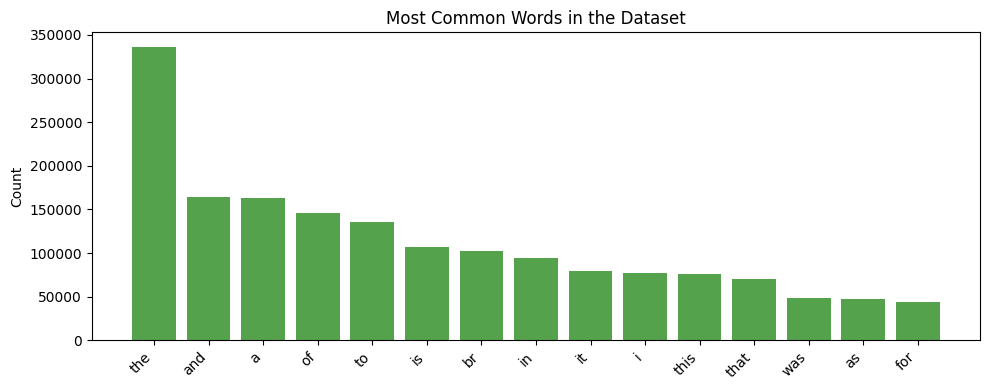

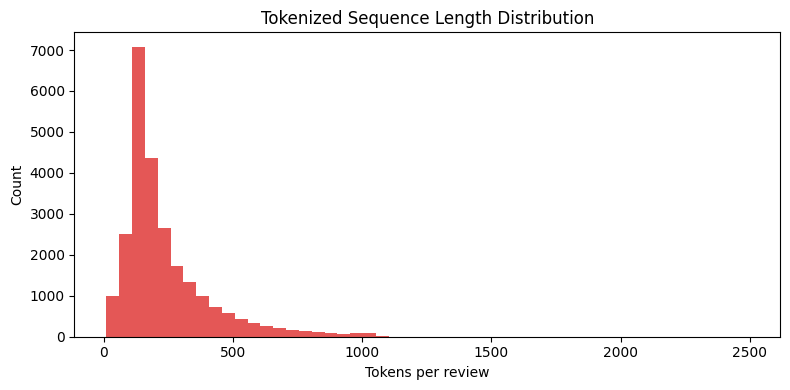

In [47]:
# Data preparation (tokenize text and convert it into padded integer sequences)

tokenizer = Tokenizer(num_words=1000, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=100, padding='post', truncating='post')

sequence_lengths = np.array([len(sequence) for sequence in sequences])
print(f'Vocabulary size: {len(tokenizer.word_index)}')
print(f'Average tokenized sequence length: {sequence_lengths.mean():.2f}')
print(f'Max tokenized sequence length: {sequence_lengths.max()}')

print('\nOriginal review sample:')
print(texts[0][:400])

print('\nTokenized sequence sample:')
print(sequences[0][:20])

print('\nPadded sequence sample:')
print(padded_sequences[0][:20])

most_common_words = Counter(tokenizer.word_counts).most_common(15)
words, counts = zip(*most_common_words)

plt.figure(figsize=(10, 4))
plt.bar(words, counts, color='#54a24b')
plt.title('Most Common Words in the Dataset')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(sequence_lengths, bins=50, color='#e45756')
plt.title('Tokenized Sequence Length Distribution')
plt.xlabel('Tokens per review')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Building the model

This section creates the neural network that will learn from the padded review sequences.

## How to think about it
- The input layer says what shape the model expects.
- The embedding layer learns a dense vector representation for each word.
- The bidirectional LSTM reads the sequence in both directions, which helps with language context.
- The dense layers combine features and make the final yes/no prediction.

## Why the summary is important
- It shows the output shape after each layer.
- It tells you how many trainable parameters the model has.
- It helps you spot shape mismatches before training starts.


In [48]:
# Building the neural network model

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(100,)),
    tf.keras.layers.Embedding(input_dim=1000, output_dim=16, mask_zero=True),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 100, 16)        │        16,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_8 (Bidirectional) │ (None, 128)            │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,793 (257.00 KB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 0 (0.00 B)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(20000, 100)
(20000,)
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.7193 - loss: 0.5361 - val_accuracy: 0.7806 - val_loss: 0.4560
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.7988 - loss: 0.4345 - val_accuracy: 0.7962 - val_loss: 0.4395
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.8060 - loss: 0.4201 - val_accuracy: 0.7710 - val_loss: 0.4721
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.8153 - loss: 0.4050 - val_accuracy: 0.7886 - val_loss: 0.4491
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.8227 - loss: 0.3927 - val_accuracy: 0.7920 - val_loss: 0.4462
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.8337 - loss: 0.3724 - val_accuracy: 0.7804 - val_loss: 0.4591
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.8436 - loss: 0.3555 - val_accuracy: 0.7804 - val_loss: 0.4690
Epoch 8/10
625/625 ━

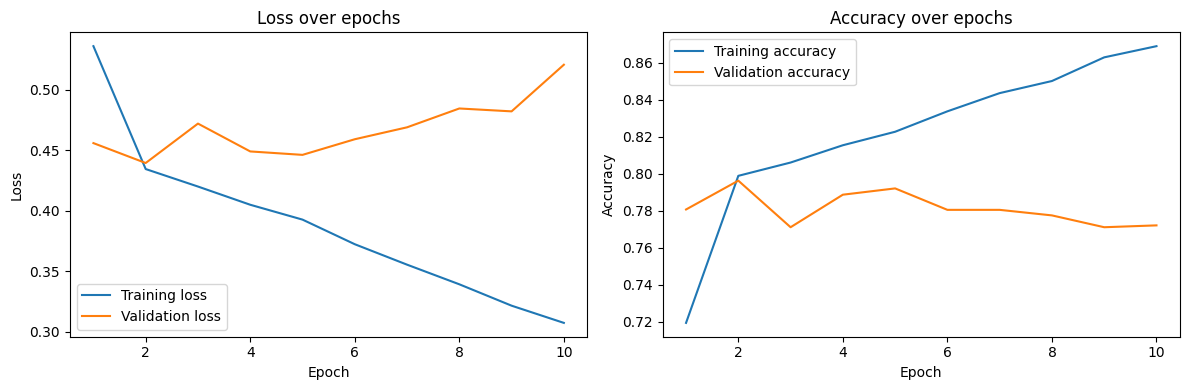

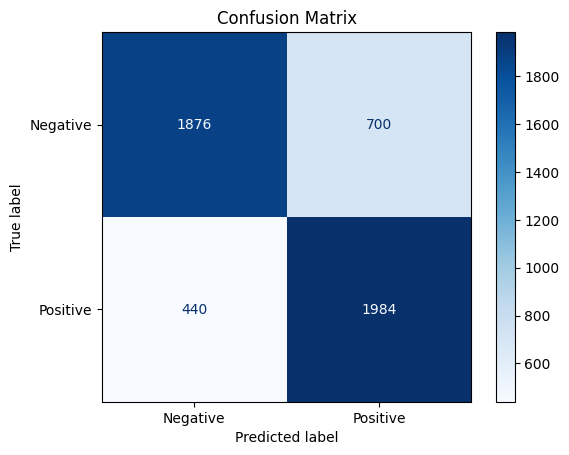

              precision    recall  f1-score   support

    Negative       0.81      0.73      0.77      2576
    Positive       0.74      0.82      0.78      2424

    accuracy                           0.77      5000
   macro avg       0.77      0.77      0.77      5000
weighted avg       0.78      0.77      0.77      5000



In [49]:
# Training the model
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=42)

X_train = np.asarray(X_train)
X_test = np.asarray(X_test)
y_train = np.asarray(y_train)
y_test = np.asarray(y_test)

print(type(X_train))
print(type(y_train))

print(X_train.shape)
print(y_train.shape)

history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=32)

history_dict = history.history
epochs_range = range(1, len(history_dict['loss']) + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_dict['loss'], label='Training loss')
plt.plot(epochs_range, history_dict['val_loss'], label='Validation loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_dict['accuracy'], label='Training accuracy')
plt.plot(epochs_range, history_dict['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

In [51]:
# Model evaluation
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7720 - loss: 0.5207
Test Accuracy: 0.7720000147819519


In [52]:
# Model deployment
model.save("sentiment_analysis_model.keras")